Úkol 2: Test hypotézy

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency, mannwhitneyu, shapiro

In [2]:
# Načtení dat
accidents = pd.read_pickle('accidents.pkl.gz')
vehicles = pd.read_pickle('vehicles.pkl.gz')

# Zkontrolujeme první řádky dat
accidents.head(), vehicles.head()


(             p1         p2a   p2b  p4a  p4b  p4c  p5a  p6  p7  p8  ...  p27  \
 0   10623000002  01.01.2023  1730    1    7   12    2   5   0   0  ...    0   
 1   60223000039  10.01.2023   916    6    2   10    1   3   0   3  ...    0   
 2      23000455  15.01.2023  1930    0   11   20    1   1   4   0  ...   10   
 3   70623000019  10.01.2023   815    7    6   18    2   5   0   0  ...    0   
 4  161723000024  11.01.2023  1730   16   17   17    2   5   0   0  ...    0   
 
    p28  p34  p35  p36    p37     p38  p39       date  region  
 0    1    1    0    1   16.0  7532.0  NaN 2023-01-01     STC  
 1    5    1   10    6    NaN     NaN  6.0 2023-01-10     JHM  
 2    1    2    0    6    NaN     NaN  NaN 2023-01-15     PHA  
 3    1    1    0    2  460.0  1275.0  NaN 2023-01-10     MSK  
 4    1    1    0    6    NaN     NaN  NaN 2023-01-11     VYS  
 
 [5 rows x 40 columns],
          p1  id_vozidla  p44  p45a  p45b  p45d  p45f p47  p48a  p48b  ...  \
 0  22000026           1    3 

Hypotéza 1: Na silnicích první třídy se byly nehody s následky na zdraví se stejnou pravděpodobností jako na dálnicích.
Test nezávislosti (𝜒² test)

𝜒² test nezávislosti zjišťuje, zda mezi dvěma kategoriálními proměnnými existuje statistická závislost.
V našem případě:
    Proměnná 1: Typ silnice (p36 – dálnice nebo silnice první třídy),
    Proměnná 2: Typ následků (p9 – hmotná škoda nebo následky na zdraví).

Test porovnává pozorované četnosti (co jsme naměřili) s očekávanými četnostmi (co bychom očekávali, kdyby obě proměnné byly nezávislé)

In [3]:
# Načtení dat
vehicles = pd.read_pickle("vehicles.pkl.gz")
accidents = pd.read_pickle("accidents.pkl.gz")

# Filtrace: nehody na dálnicích (p36 == 0) a silnicích první třídy (p36 == 1)
accidents_filtered = accidents[accidents['p36'].isin([0, 1])]

# Kontingenční tabulka: četnost nehod podle typu silnice a typu následků (hmotná škoda vs. zdraví)
contingency_table = pd.crosstab(accidents_filtered['p36'], accidents_filtered['p9'])

# Pojmenujeme řádky a sloupce pro čitelnost
contingency_table.index = ['Highway (p36=0)', 'First-class Road (p36=1)']
contingency_table.columns = ['Material Damage (p9=0)', 'Health Consequences (p9=1)']

print("Contingency Table:")
print(contingency_table)

# Aplikace 𝜒² testu nezávislosti
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

# Výstupy testu
print(f"\nChi-squared test result:")
print(f"Chi-squared statistic: {chi2}")
print(f"p-value: {p_value}")
print(f"Degrees of freedom: {dof}")
print("\nExpected frequencies:")
print(expected)

# Interpretace výsledků
if p_value < 0.05:
    print("\nVýsledek: Zamítáme hypotézu. Typ následků závisí na typu silnice.")
else:
    print("\nVýsledek: Nezamítáme hypotézu. Typ následků nezávisí na typu silnice.")

Contingency Table:
                          Material Damage (p9=0)  Health Consequences (p9=1)
Highway (p36=0)                             1247                        6674
First-class Road (p36=1)                    7059                       14773

Chi-squared test result:
Chi-squared statistic: 794.1532980454858
p-value: 1.0075002730159729e-174
Degrees of freedom: 1

Expected frequencies:
[[ 2211.26696468  5709.73303532]
 [ 6094.73303532 15737.26696468]]

Výsledek: Zamítáme hypotézu. Typ následků závisí na typu silnice.


Komentář k výsledkům a jejich interpretace:

Kontingenční tabulka:
    Pozorované četnosti ukazují:
        Na dálnicích (p36=0) bylo 1247 nehod s hmotnou škodou a 6674 nehod s následky na zdraví.
        Na silnicích první třídy (p36=1) bylo 7059 nehod s hmotnou škodou a 14773 nehod s následky na zdraví.
    Vidíme, že nehody na dálnicích častěji vedou k následkům na zdraví, zatímco na silnicích první třídy je počet hmotných škod relativně vyšší.

Výsledek 𝜒² testu:

    𝜒² statistika: 794.15 je velmi vysoká hodnota, což značí významný rozdíl mezi pozorovanými a očekávanými četnostmi.
    p-hodnota: 1.01×10−1741.01×10−174 je extrémně nízká, mnohem menší než obvyklá hladina významnosti 0.05.
    Stupně volnosti: 1, protože máme 2 kategorie pro každou proměnnou (p36 a p9) → df=(2−1)(2−1)=1df=(2−1)(2−1)=1.

Interpretace:

    Extrémně nízká p-hodnota jasně ukazuje, že rozdíly mezi typy silnic a typy následků nejsou náhodné. Hypotézu zamítáme.

Očekávané četnosti:

    Očekávané četnosti jsou hodnoty, které bychom očekávali, pokud by typ následků (p9) byl nezávislý na typu silnice (p36).
        Např. pro dálnice (p36=0) a hmotné škody (p9=0) očekáváme 2211.272211.27 nehod (místo pozorovaných 1247).
        To ukazuje, že nehody s hmotnými škodami jsou na dálnicích mnohem méně časté, než by očekávalo rozdělení nezávislých proměnných.
    Naopak na silnicích první třídy (p36=1) vidíme vyšší počet nehod s hmotnými škodami, než by odpovídalo očekávání.

Závěr:

    Typ následků na zdraví nebo majetku závisí na typu silnice.
    Silnice první třídy mají relativně vyšší pravděpodobnost nehod s hmotnými škodami, zatímco na dálnicích je vyšší pravděpodobnost nehod s následky na zdraví.

Hypotéza 2: Škoda při nehodách trolejbusů je nižší, než při nehodách autobusů a tato odchylka je statisticky významná.

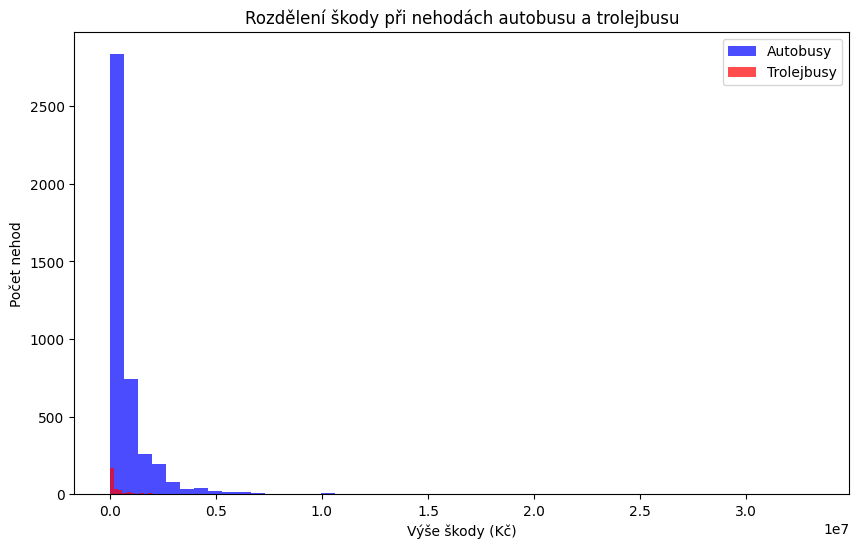

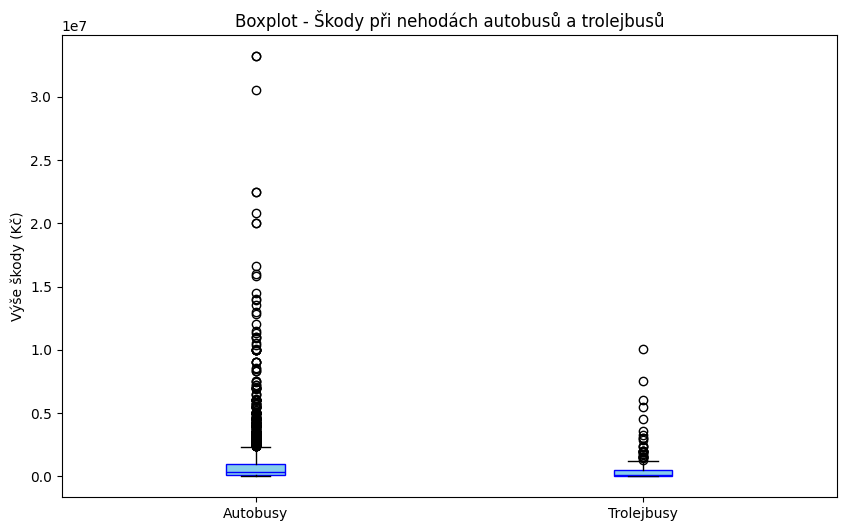

In [4]:
# Načtení dat
vehicles = pd.read_pickle("vehicles.pkl.gz")
accidents = pd.read_pickle("accidents.pkl.gz")

# Výběr relevantních sloupců
vehicles = vehicles[['p1', 'p44']]
accidents = accidents[['p1', 'p14*100']]

# Propojení obou datasetů přes sloupec p1 (accident_id)
df = pd.merge(accidents[['p1', 'p14*100']], vehicles[['p1', 'p44']], on='p1')

# Filtrace pro autobusy (p44 == 8) a trolejbusy (p44 == 11)
df_buses = df[df['p44'] == 8]  # Autobusy
df_trolleybuses = df[df['p44'] == 11]  # Trolejbusy

# Získání hodnot škod pro obě kategorie
damage_buses = df_buses['p14*100']
damage_trolleybuses = df_trolleybuses['p14*100']

# Vykreslení histogramu pro autobusy a trolejbusy
plt.figure(figsize=(10, 6))

# Histogram pro autobusy
plt.hist(damage_buses, bins=50, alpha=0.7, label='Autobusy', color='blue')

# Histogram pro trolejbusy
plt.hist(damage_trolleybuses, bins=50, alpha=0.7, label='Trolejbusy', color='red')

# Nastavení grafu
plt.title('Rozdělení škody při nehodách autobusu a trolejbusu')
plt.xlabel('Výše škody (Kč)')
plt.ylabel('Počet nehod')
plt.legend()

plt.show()

# Vykreslení boxplotu pro autobusy a trolejbusy
plt.figure(figsize=(10, 6))

# Boxplot pro autobusy a trolejbusy
plt.boxplot([damage_buses, damage_trolleybuses], tick_labels=['Autobusy', 'Trolejbusy'], patch_artist=True, 
            boxprops=dict(facecolor='skyblue', color='blue'), medianprops=dict(color='blue'))

plt.title('Boxplot - Škody při nehodách autobusů a trolejbusů')
plt.ylabel('Výše škody (Kč)')
plt.show()

In [5]:
# Shapiro-Wilk test pro autobusy
stat_buses, p_value_buses = shapiro(damage_buses)

# Shapiro-Wilk test pro trolejbusy
stat_trolleybuses, p_value_trolleybuses = shapiro(damage_trolleybuses)

print(f"Shapiro-Wilk test pro autobusy: Statistik = {stat_buses}, p-hodnota = {p_value_buses}")
print(f"Shapiro-Wilk test pro trolejbusy: Statistik = {stat_trolleybuses}, p-hodnota = {p_value_trolleybuses}")


Shapiro-Wilk test pro autobusy: Statistik = 0.4195834330693655, p-hodnota = 1.2436178812799434e-79
Shapiro-Wilk test pro trolejbusy: Statistik = 0.4836681842615691, p-hodnota = 2.6017839699736644e-28


In [6]:
# Mann-Whitney U test pro porovnání škod mezi autobusy a trolejbusy
u_stat, p_value = mannwhitneyu(damage_buses, damage_trolleybuses)

print(f"Mann-Whitney U test: U-statistika = {u_stat}, p-hodnota = {p_value}")

Mann-Whitney U test: U-statistika = 787252.5, p-hodnota = 2.471649603120307e-13


Výsledky a interpretace hypotézy 2:
1. Shapiro-Wilk test: Testování normality

Shapiro-Wilk test byl použit pro zjištění, zda jsou data normálně rozdělená.

    Pro autobusy:
        Statistik: 0.41960.4196
        p-hodnota: 1.24×10−791.24×10−79
    Pro trolejbusy:
        Statistik: 0.48370.4837
        p-hodnota: 2.60×10−282.60×10−28

Interpretace:

    p-hodnota je u obou případů extrémně malá (menší než 0.05), což znamená, že nemůžeme předpokládat, že data jsou normálně rozdělená.
    Data pro škody při nehodách autobusů a trolejbusů nejsou normálně rozdělená, a proto není vhodné použít parametrický test, jako je t-test. Místo toho byl správně použit neparametrický Mann-Whitney U test.


2. Mann-Whitney U test: Porovnání škod mezi autobusy a trolejbusy

Mann-Whitney U test byl použit k porovnání mediánů (nebo obecně rozložení) škod při nehodách autobusů a trolejbusů.

    U-statistika: 787252.5787252.5
    p-hodnota: 2.47×10−132.47×10−13

Interpretace:

    p-hodnota je výrazně menší než hladina významnosti α=0.05. To znamená, že zamítáme hypotézu, která tvrdí, že škoda při nehodách trolejbusů je nižší, než při nehodách autobusů.
    Existuje statisticky významný rozdíl mezi škodami při nehodách autobusů a trolejbusů.
    
Závěr:

    Na základě výsledku Mann-Whitney U testu je rozdíl mezi škodami při nehodách autobusů a trolejbusů statisticky významný.
    Test neříká, zda jsou škody vyšší nebo nižší – k tomu je potřeba se podívat na mediány nebo rozložení dat (např. z histogramu nebo boxplotu).
    Boxplot ukazuje, že škody jsou vyšší u autobusů než u trolejbusů.